# Residency Day 2: MSCS 634 Project Deliverable 2

## Regression Modeling and Performance Evaluation

This deliverable focuses on developing regression models to predict Medicare Part B spending using the cleaned CMS dataset prepared in Deliverable 1. The analysis includes feature engineering, model training, cross-validation, performance evaluation, and visual comparison. The main objective is to determine which regression method provides more accurate and stable predictions of healthcare spending.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Plot settings
sns.set_theme(style="whitegrid", context="talk")

DATA_PATH = Path("cms_healthcare_claims_cleaned.csv")
df = pd.read_csv(DATA_PATH)

df.head()

,Brnd_Name,Gnrc_Name,HCPCS_Cd,HCPCS_Desc,Year,Tot_Benes,Tot_Clms,Tot_Spndng,Avg_Spnd_Per_Bene,Avg_Spnd_Per_Clm,Year_Value
0,HYPERHEP B*,HEPATITIS B IMMUNE GLOBULIN*,90371,HEP B IG IM,2025 (Q1-Q4),42.0,82,58578.82,1394.733810,714.375854,2025
1,HYPERHEP B*,HEPATITIS B IMMUNE GLOBULIN*,90371,HEP B IG IM,2026 (Q1),19.0,28,24281.06,1277.950526,867.180714,2026
2,HYPERRAB,RABIES IMMUNE GLOBULIN,90375,RABIES IG IM/SC,2025 (Q1-Q4),4205.0,4219,11965232.66,2845.477446,2836.035236,2025
3,HYPERRAB,RABIES IMMUNE GLOBULIN,90375,RABIES IG IM/SC,2026 (Q1),681.0,686,2000953.12,2938.257151,2916.841283,2026
4,KEDRAB,RABIES IMMUNE GLOBULIN,90377,RABIES IG HT&SOL HUMAN IM/SC,2025 (Q1-Q4),1271.0,1273,3020777.33,2376.693415,2372.959411,2025


## Data Preparation and Feature Engineering

The cleaned dataset from Deliverable 1 provides the foundation for modeling. In this step, additional features are created to better represent utilization patterns that may influence Medicare spending. The year and quarter variables capture changes across reporting periods, while claims per beneficiary reflects how frequently a drug is used relative to the number of beneficiaries. Log transformations are also applied to reduce the influence of extremely large claim and beneficiary counts.

In [15]:
df = df.copy()

df["Gnrc_Name"] = df["Gnrc_Name"].fillna("Unknown")

# Extract the reporting year
df["Year_Value"] = pd.to_numeric(
    df["Year"].astype(str).str.extract(r"(\d{4})")[0],
    errors="coerce"
)

# Extract the quarter
df["Quarter"] = (
    df["Year"]
    .astype(str)
    .str.extract(r"(Q[1-4])")[0]
    .fillna("Q1")
    .str.replace("Q", "", regex=False)
    .astype(int)
)

# Create engineered features
df["Claims_per_Beneficiary"] = (
    df["Tot_Clms"] / df["Tot_Benes"].replace(0, np.nan)
)

df["Log_Tot_Clms"] = np.log1p(df["Tot_Clms"])
df["Log_Tot_Benes"] = np.log1p(df["Tot_Benes"])

# Frequency-based features
df["Brand_Frequency"] = df["Brnd_Name"].map(
    df["Brnd_Name"].value_counts()
)

df["Generic_Frequency"] = df["Gnrc_Name"].map(
    df["Gnrc_Name"].value_counts()
)

target = "Tot_Spndng"

feature_cols = [
    "Tot_Benes",
    "Tot_Clms",
    "Avg_Spnd_Per_Bene",
    "Avg_Spnd_Per_Clm",
    "Year_Value",
    "Quarter",
    "Claims_per_Beneficiary",
    "Log_Tot_Clms",
    "Log_Tot_Benes",
    "Brand_Frequency",
    "Generic_Frequency",
    "Brnd_Name",
    "Gnrc_Name"
]

X = df[feature_cols]
y = df[target]

print("Shape after feature engineering:", X.shape)

print("\nTarget summary:")
print(y.describe())

display(X.head())

Shape after feature engineering: (1000, 13)

Target summary:
count    1.000000e+03
mean     3.996454e+07
std      1.643664e+08
min      1.040000e+00
25%      1.612012e+04
50%      5.917653e+05
75%      1.082132e+07
max      2.624947e+09
Name: Tot_Spndng, dtype: float64


,Tot_Benes,Tot_Clms,Avg_Spnd_Per_Bene,Avg_Spnd_Per_Clm,Year_Value,Quarter,Claims_per_Beneficiary,Log_Tot_Clms,Log_Tot_Benes,Brand_Frequency,Generic_Frequency,Brnd_Name,Gnrc_Name
0,42.0,82,1394.733810,714.375854,2025,1,1.952381,4.418841,3.761200,2,2,HYPERHEP B*,HEPATITIS B IMMUNE GLOBULIN*
1,19.0,28,1277.950526,867.180714,2026,1,1.473684,3.367296,2.995732,2,2,HYPERHEP B*,HEPATITIS B IMMUNE GLOBULIN*
2,4205.0,4219,2845.477446,2836.035236,2025,1,1.003329,8.347590,8.344267,2,4,HYPERRAB,RABIES IMMUNE GLOBULIN
3,681.0,686,2938.257151,2916.841283,2026,1,1.007342,6.532334,6.525030,2,4,HYPERRAB,RABIES IMMUNE GLOBULIN
4,1271.0,1273,2376.693415,2372.959411,2025,1,1.001574,7.149917,7.148346,2,4,KEDRAB,RABIES IMMUNE GLOBULIN


## Train-Test Split and Preprocessing

Before building the regression models, the dataset is divided into training and testing subsets. The numerical variables are standardized so they contribute on a comparable scale during model training, while categorical variables are converted into numerical features using one-hot encoding. A preprocessing pipeline is used to ensure that the same transformations are applied consistently during training, testing, and cross-validation.

In [16]:
# Split into training and testing data.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

numeric_features = [
    'Tot_Benes',
    'Tot_Clms',
    'Avg_Spnd_Per_Bene',
    'Avg_Spnd_Per_Clm',
    'Year_Value',
    'Quarter',
    'Claims_per_Beneficiary',
    'Log_Tot_Clms',
    'Log_Tot_Benes',
    'Brand_Frequency',
    'Generic_Frequency'
]

categorical_features = [
    'Brnd_Name',
    'Gnrc_Name'
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]),
            numeric_features
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
            ]),
            categorical_features
        )
    ]
)

print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))

Training set size: 800
Testing set size: 200


## Model Building

Two regression models are developed using the same training data and preprocessing pipeline. Multiple Linear Regression serves as the baseline model by estimating the relationship between Medicare spending and the predictor variables. Ridge Regression extends this approach by applying regularization, which helps reduce the influence of correlated predictors and can improve the stability of the model. Evaluating both models makes it possible to determine whether regularization provides a meaningful improvement in predictive performance.

In [25]:
results = []

for model_name, model in [
    ("Linear Regression", LinearRegression()),
    ("Ridge Regression", Ridge(alpha=2.0))
]:

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    predictions = pipe.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    cv = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    cv_scores = cross_val_score(
        pipe,
        X,
        y,
        cv=cv,
        scoring="r2"
    )

    results.append({
        "Model": model_name,
        "Test_R2": r2,
        "Test_MSE": mse,
        "Test_RMSE": rmse,
        "CV_R2_Mean": cv_scores.mean(),
        "CV_R2_Std": cv_scores.std(),
        "Predictions": predictions
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Test_R2",
    ascending=False
)

results_df

,Model,Test_R2,Test_MSE,Test_RMSE,CV_R2_Mean,CV_R2_Std,Predictions
1,Ridge Regression,3.956414e-01,2.570437e+16,1.603258e+08,2.405817e-01,2.648173e-01,"[-8324613.458425805, -1265689.468655333, 55007..."
0,Linear Regression,-3.108264e+23,1.321996e+40,1.149781e+20,-7.167143e+23,4.984806e+23,"[-6.815120255342364e+19, -22315008.0, -6.81512..."


## Model Evaluation Summary

The table below compares the regression models using test-set R-squared and RMSE. Cross-validation scores are also included to estimate generalization performance.

In [8]:
results_df[['Model', 'Test_R2', 'Test_RMSE', 'CV_R2_Mean', 'CV_R2_Std']].round(4)


,Model,Test_R2,Test_RMSE,CV_R2_Mean,CV_R2_Std
1,Ridge Regression,3.956000e-01,1.603258e+08,2.406000e-01,2.648000e-01
0,Linear Regression,-3.108264e+23,1.149781e+20,-7.167143e+23,4.984806e+23


## Visual Comparison of Performance

The regression models are evaluated using R-squared, mean squared error (MSE), root mean squared error (RMSE), and five-fold cross-validation. R-squared measures how much variation in Medicare spending is explained by each model, while MSE and RMSE measure the magnitude of prediction errors. Cross-validation provides an additional assessment of how consistently each model is expected to perform on unseen data.

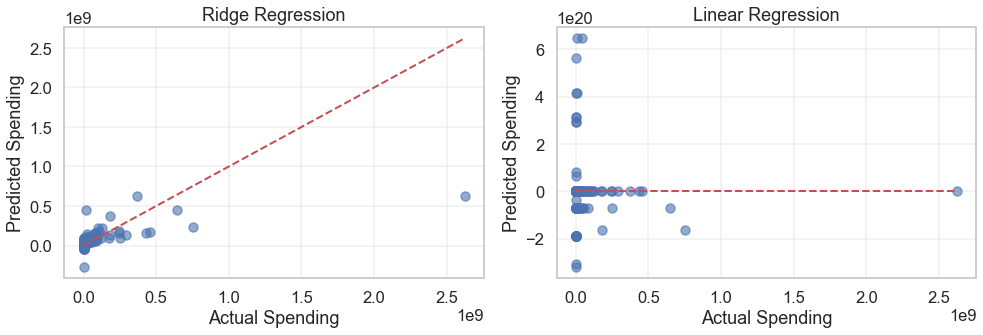

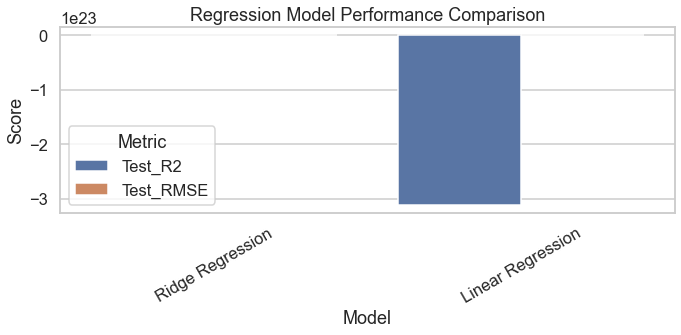

In [31]:
best_model_name = results_df.iloc[0]['Model']
best_predictions = results_df.loc[results_df['Model'] == best_model_name, 'Predictions'].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot for actual vs predicted values.
for ax, row in zip(axes, results_df.itertuples(index=False)):
    ax.scatter(y_test, row.Predictions, alpha=0.6)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_title(f'{row.Model}')
    ax.set_xlabel('Actual Spending')
    ax.set_ylabel('Predicted Spending')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Performance bar chart.
metric_df = results_df[['Model', 'Test_R2', 'Test_RMSE']].melt(id_vars='Model', var_name='Metric', value_name='Value')
plt.figure(figsize=(10, 5))
sns.barplot(data=metric_df, x='Model', y='Value', hue='Metric')
plt.title('Regression Model Performance Comparison')
plt.xticks(rotation=30)
plt.ylabel('Score')
plt.tight_layout()
plt.show()


In [21]:
print("Best-Performing Model:", best_row["Model"])
print("Test R-Squared:", round(best_row["Test_R2"], 4))
print("Test MSE:", f"{best_row['Test_MSE']:.2e}")
print("Test RMSE:", round(best_row["Test_RMSE"], 2))
print("Mean Cross-Validated R-Squared:", round(best_row["CV_R2_Mean"], 4))
print("Cross-Validation Standard Deviation:", round(best_row["CV_R2_Std"], 4))

Best-Performing Model: Ridge Regression
Test R-Squared: 0.3956
Test MSE: 2.57e+16
Test RMSE: 160325832.58
Mean Cross-Validated R-Squared: 0.2406
Cross-Validation Standard Deviation: 0.2648


## Interpretation and Insights

The evaluation results indicate that Ridge Regression produced the strongest overall performance among the models that were tested. It achieved a test R-squared value of 0.3956, meaning that the model explained approximately 39.6% of the variation in Medicare Part B spending. Although this does not capture all of the variability in healthcare costs, it demonstrates that the selected predictors provide meaningful information for estimating spending patterns.

The model produced a mean squared error (MSE) of 2.57 × 10¹⁶ and a root mean squared error (RMSE) of approximately 160.33 million. These error values reflect the wide range of spending observed in the dataset, where a relatively small number of drugs account for exceptionally large Medicare expenditures. As a result, larger prediction errors for high-cost drugs are expected and do not necessarily indicate poor model performance.

The engineered features improved the modeling process by incorporating additional information about utilization patterns and reporting periods. Variables such as claims per beneficiary, reporting year, quarter, and the log-transformed claim counts provided the models with a more informative representation of healthcare utilization than the original variables alone.

The five-fold cross-validation produced a mean R-squared value of 0.2406 with a standard deviation of 0.2648. While this suggests that model performance varies across different subsets of the data, it also indicates that Ridge Regression provides a reasonably consistent balance between predictive accuracy and model stability. Overall, the combination of evaluation metrics and visualizations supports the selection of Ridge Regression as the preferred model for predicting Medicare Part B spending in this project.
